<a href="https://colab.research.google.com/github/rtajeong/M4_2026/blob/main/lab_67_human_action_by_sensors_rev4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 사람의 동작을 스마트폰의 가속도 센서 데이터로 분류하는 예
- from https://www.cis.fordham.edu/wisdm/dataset.php
- sampled at every 50 msec
- 매 100 개씩의 샘플을 보고 모두 동일한 동작 (y)으로 되어 있는 부분만을 X 데이터로 취한다.
  - X.shape = (C,100,3), y.shape=(C,)
- 여러 형태의 딥러닝 모델을 이용해 동작을 예측한다.

In [1]:
from matplotlib import pyplot as plt
%matplotlib inline
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

from sklearn import metrics
from sklearn.metrics import classification_report
from sklearn import preprocessing

from tensorflow import keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, Reshape, GRU, Input
from tensorflow.keras.layers import Conv1D, Conv2D, MaxPooling1D, MaxPooling2D, GlobalAveragePooling1D
from tensorflow.keras import utils

## 여섯개의 레이블을 사용한다.
- Downstairs, Jogging, Sitting, Standing, Upstairs, Walking


In [5]:
# 소수점 세 자리만 표시
pd.options.display.float_format = '{:.3f}'.format
np.set_printoptions(precision=3)

LABELS = ['Downstairs',
          'Jogging',
          'Sitting',
          'Standing',
          'Upstairs',
          'Walking']

- download data from https://www.cis.fordham.edu/wisdm/dataset.php and save it in the current directory
- 11.138 Mbytes

In [8]:
!ls -l

total 11144
drwxr-xr-x 1 root root     4096 Jun  4 13:32 sample_data
-rw-r--r-- 1 root root 11404612 Jul 12 13:46 WISDM_ar_latest.tar.gz


In [9]:
!gunzip WISDM_ar_latest.tar.gz

In [10]:
!tar -xf ./WISDM_ar_latest.tar

In [11]:
!ls -l WISDM_ar_v1.1

total 50336
-rw------- 1 1000 1000     2074 Dec  2  2012 readme.txt
-rw------- 1 1000 1000     1449 Dec  2  2012 WISDM_ar_v1.1_raw_about.txt
-rw------- 1 1000 1000 50326282 Dec  2  2012 WISDM_ar_v1.1_raw.txt
-rw------- 1 1000 1000     2451 Dec  2  2012 WISDM_ar_v1.1_trans_about.txt
-rw------- 1 1000 1000  1203558 Dec  2  2012 WISDM_ar_v1.1_transformed.arff


In [12]:
!head -5 ./WISDM_ar_v1.1/WISDM_ar_v1.1_raw.txt

33,Jogging,49105962326000,-0.6946377,12.680544,0.50395286;
33,Jogging,49106062271000,5.012288,11.264028,0.95342433;
33,Jogging,49106112167000,4.903325,10.882658,-0.08172209;
33,Jogging,49106222305000,-0.61291564,18.496431,3.0237172;
33,Jogging,49106332290000,-1.1849703,12.108489,7.205164;


In [13]:
!tail -5 ./WISDM_ar_v1.1/WISDM_ar_v1.1_raw.txt

19,Sitting,131623371431000,9.04,-1.46,1.73;
19,Sitting,131623411592000,9.08,-1.38,1.69;
19,Sitting,131623491487000,9,-1.46,1.73;
19,Sitting,131623531465000,8.88,-1.33,1.61;



In [27]:
def read_data(file_path):
    column_names = ['user-id',
                    'activity',
                    'timestamp',
                    'x-axis',
                    'y-axis',
                    'z-axis']
    df = pd.read_csv(file_path,
                     header=None,
                     names=column_names,
                     on_bad_lines='skip')

    # 1. 마지막 컬럼의 문자열 내부에 포함된 ";"를 확실하게 제거
    df['z-axis'] = df['z-axis'].str.replace(';', '', regex=False)

    # 2. 판다스 내장 함수로 안전하고 빠르게 소수점 변환 (변환 실패 시 자동으로 NaN 처리)
    df['z-axis'] = pd.to_numeric(df['z-axis'], errors='coerce')

    # 3. 결측치 처리
    df = df.dropna(axis=0, how='any')

    return df

def convert_to_float(x):
    try:
        return np.float(x)
    except:
        return np.nan


df = read_data('./WISDM_ar_v1.1/WISDM_ar_v1.1_raw.txt')


In [28]:
df[:5]

,user-id,activity,timestamp,x-axis,y-axis,z-axis
0,33,Jogging,49105962326000,-0.695,12.681,0.504
1,33,Jogging,49106062271000,5.012,11.264,0.953
2,33,Jogging,49106112167000,4.903,10.883,-0.082
3,33,Jogging,49106222305000,-0.613,18.496,3.024
4,33,Jogging,49106332290000,-1.185,12.108,7.205


In [29]:
df.shape

(1086465, 6)

In [30]:
df['activity'].value_counts()

,count
activity,
Walking,418393
Jogging,336445
Upstairs,122869
Downstairs,100425
Sitting,59939
Standing,48394


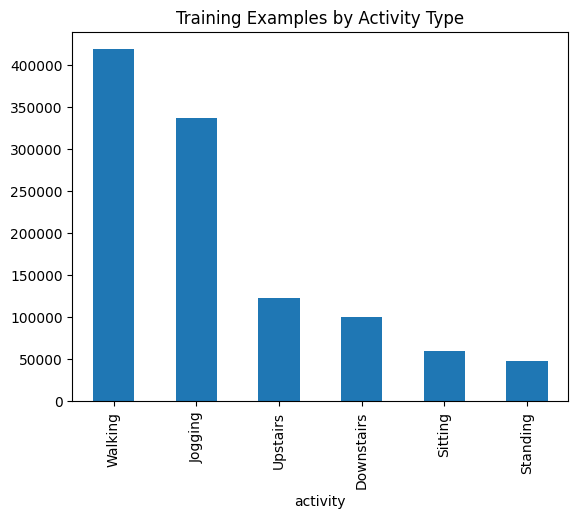

In [31]:
df['activity'].value_counts().plot(kind='bar',
                              title='Training Examples by Activity Type')
plt.show()

In [32]:
# 시각이 0이거나 음수인 샘플은 제외
df = df[df['timestamp'] > 0]
df.shape

(1073623, 6)

- 사용자별로 샘플이 몇 개인지 분포를 보자

[]

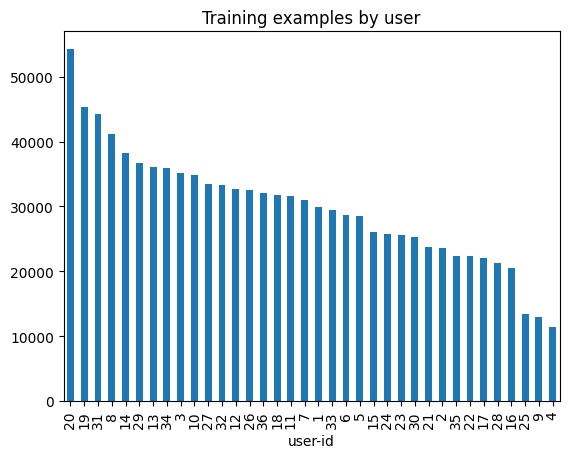

In [33]:
df['user-id'].value_counts().plot(kind='bar',
                                  title='Training examples by user')
plt.plot()

- 이제 6가지 각 행동 패턴에 대해 일부 시간의 시계열 데이터를 확인한다. 300 개의 샘플이고, 이는 300 * 50 ms = 15 초에 해당하는 시간의 그래프다.

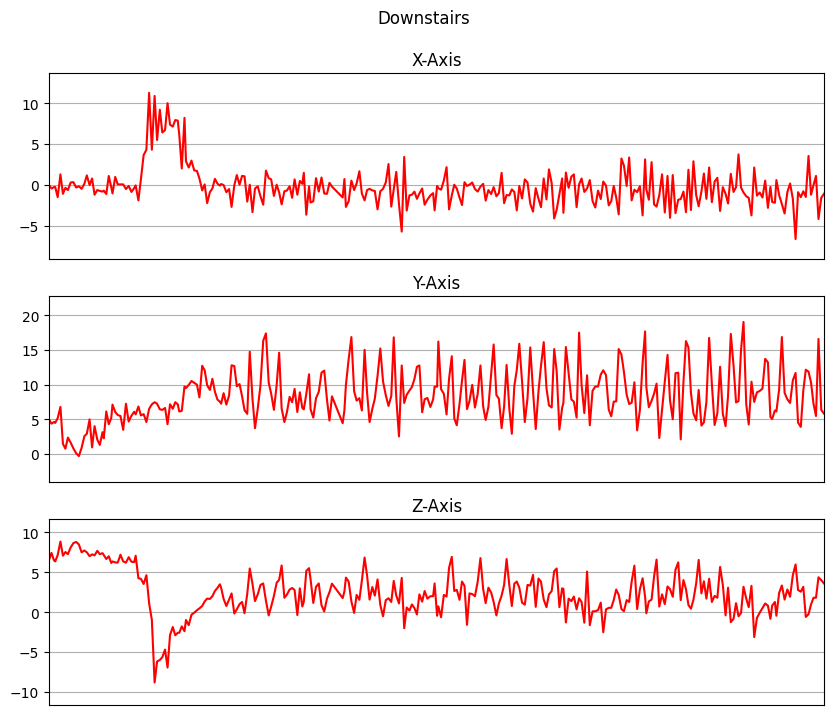

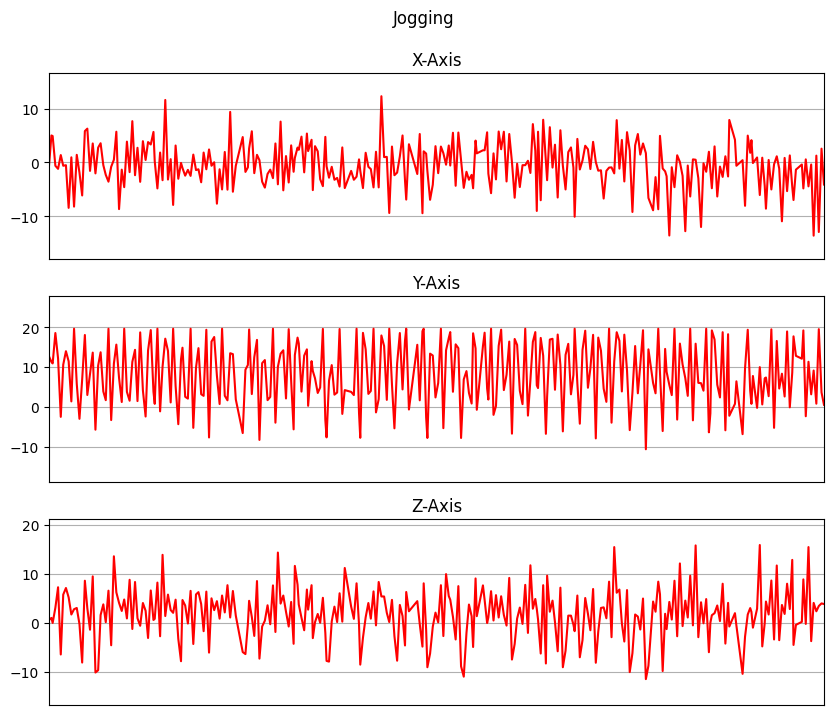

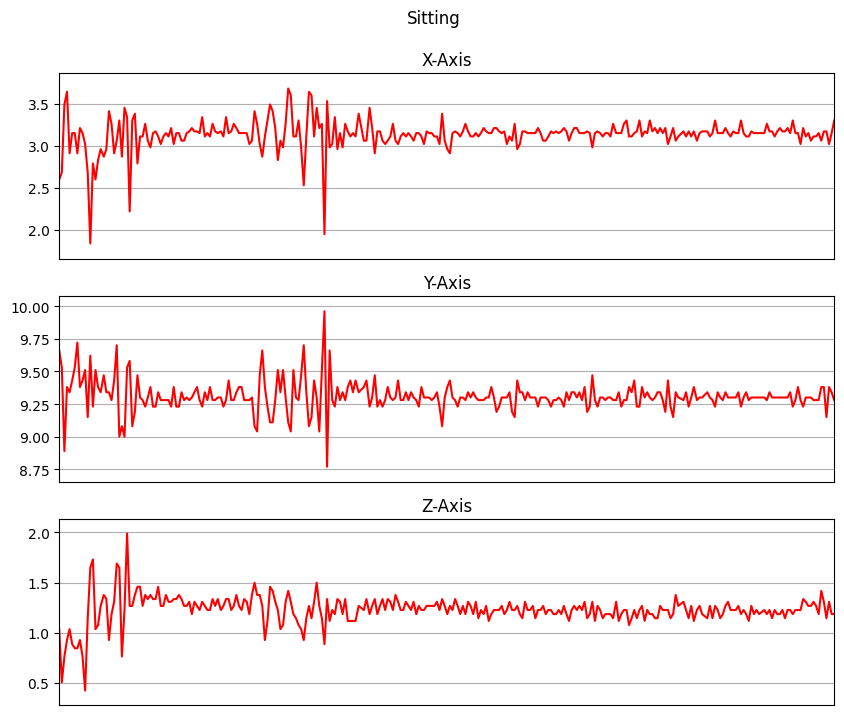

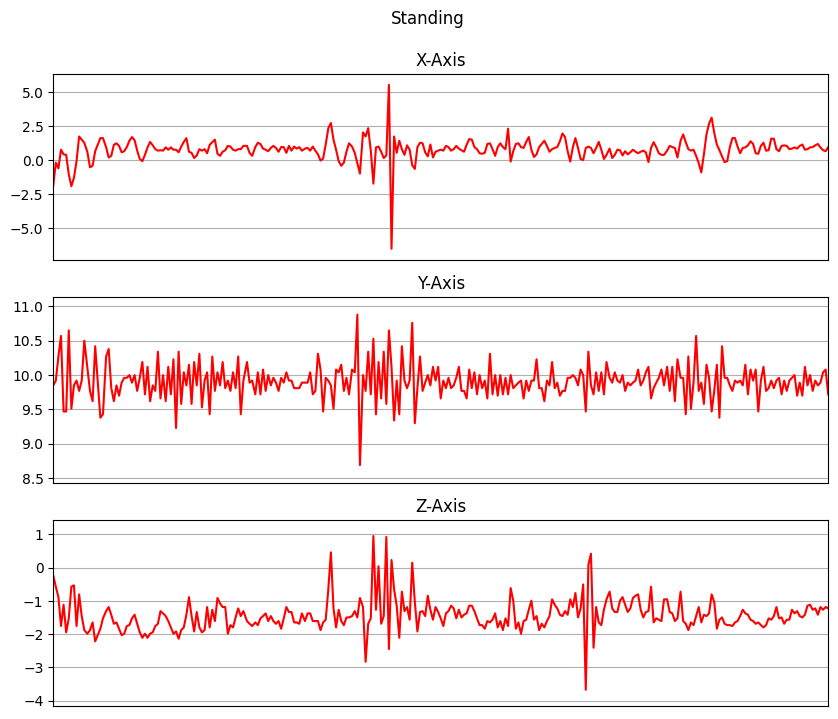

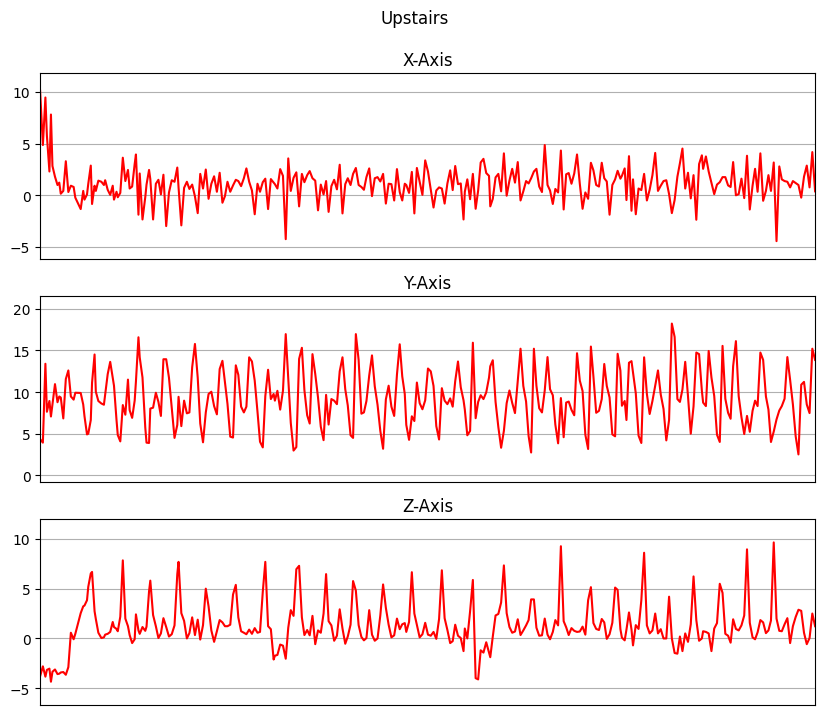

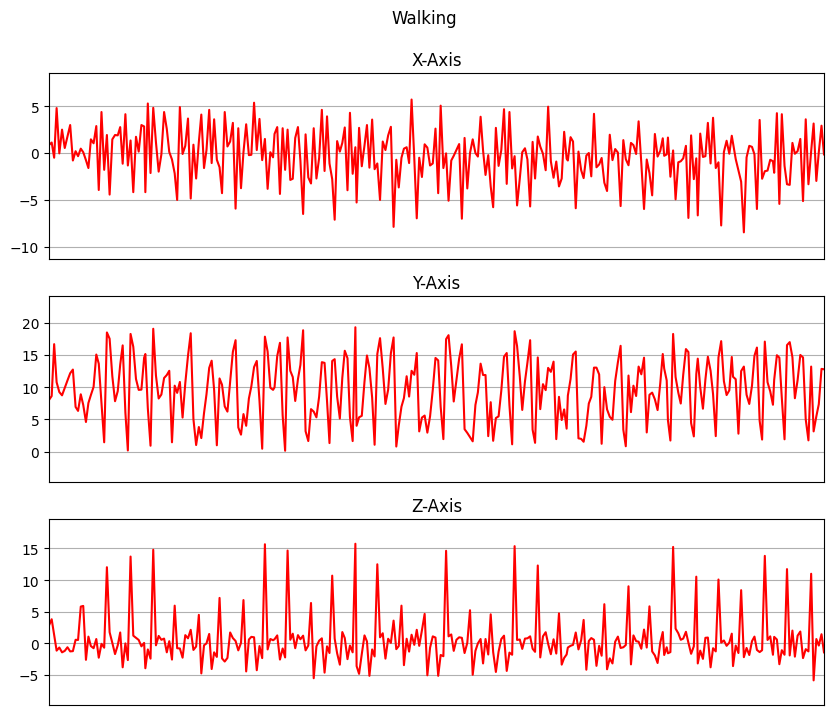

In [35]:
def plot_activity(activity, data):

    fig, (ax0, ax1, ax2) = plt.subplots(nrows=3, figsize=(10, 8), sharex=True)
    plot_axis(ax0, data['timestamp'], data['x-axis'], 'X-Axis')
    plot_axis(ax1, data['timestamp'], data['y-axis'], 'Y-Axis')
    plot_axis(ax2, data['timestamp'], data['z-axis'], 'Z-Axis')
    plt.subplots_adjust(hspace=0.2)
    fig.suptitle(activity)
    plt.subplots_adjust(top=0.90)
    plt.show()

def plot_axis(ax, x, y, title):

    ax.plot(x, y, 'r')
    ax.set_title(title)
    ax.xaxis.set_visible(False)
    ax.set_ylim([min(y) - np.std(y), max(y) + np.std(y)])
    ax.set_xlim([min(x), max(x)])
    ax.grid(True)

for activity in np.unique(df['activity']):
    subset = df[df['activity'] == activity][:300]
    plot_activity(activity, subset)

위 그래프를 보면 6 가지 동작에 대해 모양이 다른 것은 구분이 되지만 이를 프로그램이 찾게 하는 것이 목적이다.

In [36]:
le = preprocessing.LabelEncoder()
df['act'] = le.fit_transform(df['activity'].values)

In [37]:
df[:5]

,user-id,activity,timestamp,x-axis,y-axis,z-axis,act
0,33,Jogging,49105962326000,-0.695,12.681,0.504,1
1,33,Jogging,49106062271000,5.012,11.264,0.953,1
2,33,Jogging,49106112167000,4.903,10.883,-0.082,1
3,33,Jogging,49106222305000,-0.613,18.496,3.024,1
4,33,Jogging,49106332290000,-1.185,12.108,7.205,1


In [38]:
df['activity'].value_counts()   # 각 행동에 대한 분포

,count
activity,
Walking,417901
Jogging,324600
Upstairs,122598
Downstairs,100192
Sitting,59939
Standing,48393


In [39]:
df['act'].value_counts()

,count
act,
5,417901
1,324600
4,122598
0,100192
2,59939
3,48393


In [40]:
# just for checking
test = [3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,4,4,4,4,4]
stats.mode(test), stats.mode(test)[0], stats.mode(test)[1]

(ModeResult(mode=np.int64(3), count=np.int64(15)), np.int64(3), np.int64(15))

- 동작을 5초 단위 (샘플은 100 개)로 구분하고 구간 5초 내에 어떤 동작이 가장 많이 들어 있는지 찾는다.  

In [42]:
z = stats.mode(df['act'][0:100])
z[0], z[1]

(np.int64(1), np.int64(100))

In [43]:
df.columns

Index(['user-id', 'activity', 'timestamp', 'x-axis', 'y-axis', 'z-axis',
       'act'],
      dtype='object')

In [44]:
sc = preprocessing.StandardScaler()
df[['x-axis', 'y-axis', 'z-axis']] = sc.fit_transform(df[['x-axis', 'y-axis', 'z-axis']])

In [45]:
df[:5]

,user-id,activity,timestamp,x-axis,y-axis,z-axis,act
0,33,Jogging,49105962326000,-0.198,0.794,0.021,1
1,33,Jogging,49106062271000,0.627,0.584,0.115,1
2,33,Jogging,49106112167000,0.612,0.527,-0.101,1
3,33,Jogging,49106222305000,-0.186,1.658,0.547,1
4,33,Jogging,49106332290000,-0.268,0.709,1.420,1


In [46]:
df['x-axis'].values[: 100]

array([-0.198,  0.627,  0.612, -0.186, -0.268,  0.102, -0.186, -0.17 ,
       -1.316,  0.041, -1.283,  0.108, -0.369, -0.983,  0.746,  0.811,
       -0.324,  0.413, -0.391,  0.303,  0.419, -0.17 , -0.43 , -0.613,
       -0.213, -0.024,  0.728, -1.35 , -0.29 , -0.761,  0.462, -0.357,
        1.011, -0.44 ,  0.297, -0.617,  0.474, -0.03 ,  0.45 ,  0.385,
        0.722, -0.064, -0.794,  0.169, -0.574,  1.581, -0.556, -0.009,
       -1.237,  0.358, -0.534, -0.109, -0.247, -0.452, -0.296, -0.458,
        0.114, -0.302, -0.28 , -0.629,  0.169, -0.28 ,  0.251, -0.186,
       -0.091, -1.204, -0.28 , -0.822,  0.184, -0.828,  1.26 , -0.883,
       -0.186,  0.584, -0.351, -0.229,  0.279,  0.74 , -0.385,  0.108,
       -0.036, -0.613, -0.773, -0.406, -0.29 , -0.519,  0.413, -0.684,
        1.   , -0.845,  0.074, -0.635,  0.362, -0.347,  0.025,  0.303,
        0.242,  0.596, -0.363,  0.679])

In [48]:
# N개 샘플씩 끊어서 유효한 (통일된) 동작 레이블을 찾는다
N = 100
X_all = []
y = []
for i in range(0, len(df)-N+1, N):
    z = stats.mode(df['act'][i: i+N])
    action, count = z[0], z[1]
    if count == N:
        xs = df['x-axis'].values[i: i + N]
        ys = df['y-axis'].values[i: i + N]
        zs = df['z-axis'].values[i: i + N]
        X_all.append([xs, ys, zs])
        y.append(action)


In [49]:
np.shape(X_all), np.shape(y)

((10355, 3, 100), (10355,))

In [50]:
# Bring the segments into a better shape

X_all = np.asarray(X_all, dtype= np.float32)
y = np.asarray(y)

In [51]:
X_all.shape, y.shape

((10355, 3, 100), (10355,))

In [52]:
X_3 = np.transpose(X_all, (0,2,1))

In [53]:
X_3.shape

(10355, 100, 3)

In [54]:
# z-axis 성분만 추출
X = X_3[:,:,2]
X[0]

array([ 0.021,  0.115, -0.101,  0.547,  1.42 , -1.443,  1.108,  1.389,
        0.988,  0.26 ,  0.485,  0.539, -0.147, -1.788,  1.699,  0.525,
       -0.388,  1.884, -2.211, -2.115,  0.237,  0.692, -0.067,  1.275,
       -1.051,  2.74 ,  1.204,  0.755,  0.411,  0.9  ,  0.092,  1.739,
       -0.357,  1.645,  0.101, -0.221,  0.749,  0.419, -0.741,  1.284,
        0.027,  0.075,  1.619, -0.667,  2.803,  0.195,  1.108,  0.451,
        0.331,  0.891, -0.781, -1.731,  0.877,  0.644, -0.124,  1.267,
       -0.997,  1.116,  1.213,  0.707, -0.451,  1.236, -1.364,  0.948,
        0.445,  0.829,  0.084,  1.068,  0.348,  1.509,  0.132,  1.261,
        0.212, -1.341, -1.426, -0.141,  0.843,  0.155, -0.653,  1.685,
       -1.62 , -0.252, -0.004,  0.653, -0.155,  1.5  , -0.485,  2.899,
        0.724,  1.068,  0.38 , -0.252,  0.795, -0.988,  2.33 ,  1.531,
        0.684,  0.124, -0.411,  1.324], dtype=float32)

In [55]:
X.shape, y.shape

((10355, 100), (10355,))

In [56]:
LABELS

['Downstairs', 'Jogging', 'Sitting', 'Standing', 'Upstairs', 'Walking']

In [57]:
classes = len(df['act'].unique()); classes

6

In [58]:
y_hot = utils.to_categorical(y)  # one-hot encoding
y_hot.shape

(10355, 6)

In [59]:
y_hot[:3]

array([[0., 1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0.]])

In [60]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
%matplotlib inline

In [61]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2,
                                                    random_state=42)
rfc = RandomForestClassifier(n_estimators=100)
rfc.fit(X_train, y_train)
print(rfc.score(X_test,y_test))
print(rfc.predict(X_test[:10]))

0.8102366006760019
[5 5 4 4 1 3 5 5 5 5]


In [62]:
X_train.shape, y_train.shape

((8284, 100), (8284,))

- RandomforestClassifier supports an one-hot encoded target (not very common, though)

In [63]:
X_train, X_test, y_train, y_test = train_test_split(X, y_hot, test_size = 0.2,
                                                    random_state=42)
rfc = RandomForestClassifier(n_estimators=100)
rfc.fit(X_train, y_train)
rfc.score(X_test,y_test)

0.6170931916948335

In [64]:
rfc.predict(X_test[:10])

array([[0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0.],
       [0., 1., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0., 0.],
       [0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 1.]])

In [65]:
X_train.shape, y_train.shape

((8284, 100), (8284, 6))

- let's try an DNN model

In [68]:
model_m = Sequential()
model_m.add(Input(shape=(100,)))
model_m.add(Dense(100, activation='relu'))
model_m.add(Dense(100, activation='relu'))
model_m.add(Dense(6, activation='softmax'))
print(model_m.summary())

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           606 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,806 (81.27 KB)

 Trainable params: 20,806 (81.27 KB)

 Non-trainable params: 0 (0.00 B)

None


## 동작 환경 설정
- 조기 종료 (2회 동안 개선되지 않으면 종료)
- 배치 크기 400
- 이포크 50
- 훈련데이터: 검증 데이터 = 8:2


In [70]:
callbacks_list = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath='best_model.{epoch:02d}-{val_loss:.2f}.h5',
        monitor='val_loss', save_best_only=True),
    tf.keras.callbacks.EarlyStopping(monitor='val_acc', patience=3, mode='max')
]

model_m.compile(loss='categorical_crossentropy',
                optimizer='adam',
                metrics=['accuracy'])

BATCH_SIZE = 10
EPOCHS = 30

history = model_m.fit(X_train,
                      y_train,
                      batch_size=BATCH_SIZE,
                      epochs=EPOCHS,
                      callbacks=callbacks_list,
                      validation_split=0.2,
                      verbose=1)

Epoch 1/30
655/663 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8038 - loss: 0.5487

663/663 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8058 - loss: 0.5337 - val_accuracy: 0.7930 - val_loss: 0.5763
Epoch 2/30
 31/663 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8655 - loss: 0.4063

/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_acc` which is not available. Available metrics are: accuracy,loss,val_accuracy,val_loss
  current = self.get_monitor_value(logs)


663/663 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8464 - loss: 0.4110

663/663 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8453 - loss: 0.4152 - val_accuracy: 0.8075 - val_loss: 0.5721
Epoch 3/30
663/663 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8705 - loss: 0.3401 - val_accuracy: 0.7954 - val_loss: 0.6216
Epoch 4/30
663/663 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9024 - loss: 0.2741 - val_accuracy: 0.8093 - val_loss: 0.5941
Epoch 5/30
663/663 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9176 - loss: 0.2263 - val_accuracy: 0.7924 - val_loss: 0.7213
Epoch 6/30
663/663 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9332 - loss: 0.1920 - val_accuracy: 0.7954 - val_loss: 0.6888
Epoch 7/30
663/663 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9440 - loss: 0.1614 - val_accuracy: 0.7912 - val_loss: 0.7571
Epoch 8/30
663/663 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9555 - loss: 0.1324 - val_accuracy: 0.8039 - val_loss: 0.7655
Epoch 9/30
663/663 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9656 - loss: 0.1032 - val_accuracy: 0.8063 - val_

In [71]:
model_m.evaluate(X_test, y_test)

65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8054 - loss: 1.3849


[1.384894847869873, 0.8054080009460449]

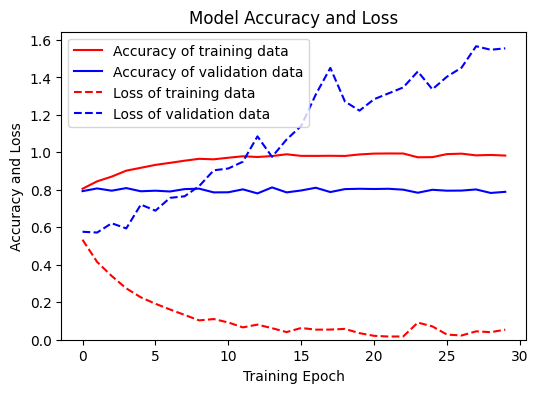

In [72]:
plt.figure(figsize=(6, 4))
plt.plot(history.history['accuracy'], 'r', label='Accuracy of training data')
plt.plot(history.history['val_accuracy'], 'b', label='Accuracy of validation data')
plt.plot(history.history['loss'], 'r--', label='Loss of training data')
plt.plot(history.history['val_loss'], 'b--', label='Loss of validation data')
plt.title('Model Accuracy and Loss')
plt.ylabel('Accuracy and Loss')
plt.xlabel('Training Epoch')
plt.ylim(0)
plt.legend()
plt.show()

In [75]:
def show_confusion_matrix(validations, predictions):

    matrix = metrics.confusion_matrix(validations, predictions)
    plt.figure(figsize=(6, 4))
    sns.heatmap(matrix,
                cmap='coolwarm',
                linecolor='white',
                linewidths=1,
                xticklabels=LABELS,
                yticklabels=LABELS,
                annot=True,
                fmt='d')
    plt.title('Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


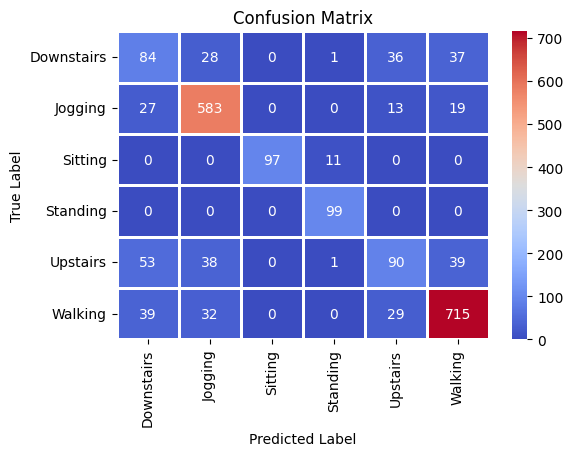

              precision    recall  f1-score   support

           0       0.41      0.45      0.43       186
           1       0.86      0.91      0.88       642
           2       1.00      0.90      0.95       108
           3       0.88      1.00      0.94        99
           4       0.54      0.41      0.46       221
           5       0.88      0.88      0.88       815

    accuracy                           0.81      2071
   macro avg       0.76      0.76      0.76      2071
weighted avg       0.80      0.81      0.80      2071



In [76]:
y_pred_test = model_m.predict(X_test)
max_y_pred_test = np.argmax(y_pred_test, axis=1)
max_y_test = np.argmax(y_test, axis=1)
show_confusion_matrix(max_y_test, max_y_pred_test)
print(classification_report(max_y_test, max_y_pred_test))

## CNN을 사용하여 성능을 개선

In [78]:
model_m = Sequential()
model_m.add(Input(shape=(N,)))
model_m.add(Reshape((N, 1)))
model_m.add(Conv1D(100, 10, activation='relu', input_shape=(N,1)))
model_m.add(Conv1D(100, 10, activation='relu'))
model_m.add(MaxPooling1D(3))
model_m.add(Conv1D(160, 10, activation='relu'))
model_m.add(GlobalAveragePooling1D())
model_m.add(Dropout(0.5))
model_m.add(Dense(6, activation='softmax'))
print(model_m.summary())

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ reshape_1 (Reshape)             │ (None, 100, 1)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 91, 100)        │         1,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 82, 100)        │       100,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 27, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 18, 160)        │       160,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_1      │ (None, 160)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 160)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 6)              │           966 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 262,326 (1.00 MB)

 Trainable params: 262,326 (1.00 MB)

 Non-trainable params: 0 (0.00 B)

None


In [79]:
callbacks_list = [
    keras.callbacks.ModelCheckpoint(
        filepath='best_model.{epoch:02d}-{val_loss:.2f}.h5',
        monitor='val_loss', save_best_only=True),
    keras.callbacks.EarlyStopping(monitor='val_acc', patience=3, mode='max')
]

model_m.compile(loss='categorical_crossentropy',
                optimizer='adam', metrics=['accuracy'])

BATCH_SIZE = 20
EPOCHS = 30

history = model_m.fit(X_train,
                      y_train,
                      batch_size=BATCH_SIZE,
                      epochs=EPOCHS,
                      callbacks=callbacks_list,
                      validation_split=0.2,
                      verbose=1)

Epoch 1/30
331/332 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.5894 - loss: 0.9910

332/332 ━━━━━━━━━━━━━━━━━━━━ 19s 50ms/step - accuracy: 0.7038 - loss: 0.7611 - val_accuracy: 0.8262 - val_loss: 0.4870
Epoch 2/30


/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_acc` which is not available. Available metrics are: accuracy,loss,val_accuracy,val_loss
  current = self.get_monitor_value(logs)


332/332 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.8233 - loss: 0.4935

332/332 ━━━━━━━━━━━━━━━━━━━━ 27s 69ms/step - accuracy: 0.8407 - loss: 0.4495 - val_accuracy: 0.8570 - val_loss: 0.3728
Epoch 3/30
331/332 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.8645 - loss: 0.3659

332/332 ━━━━━━━━━━━━━━━━━━━━ 30s 90ms/step - accuracy: 0.8704 - loss: 0.3479 - val_accuracy: 0.8841 - val_loss: 0.3066
Epoch 4/30
332/332 ━━━━━━━━━━━━━━━━━━━━ 16s 47ms/step - accuracy: 0.8873 - loss: 0.2975 - val_accuracy: 0.8775 - val_loss: 0.3331
Epoch 5/30
332/332 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.9079 - loss: 0.2560

332/332 ━━━━━━━━━━━━━━━━━━━━ 20s 46ms/step - accuracy: 0.9078 - loss: 0.2495 - val_accuracy: 0.9028 - val_loss: 0.2525
Epoch 6/30
332/332 ━━━━━━━━━━━━━━━━━━━━ 15s 46ms/step - accuracy: 0.9147 - loss: 0.2315 - val_accuracy: 0.9046 - val_loss: 0.2760
Epoch 7/30
332/332 ━━━━━━━━━━━━━━━━━━━━ 17s 51ms/step - accuracy: 0.9226 - loss: 0.2073 - val_accuracy: 0.9004 - val_loss: 0.2658
Epoch 8/30
331/332 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.9271 - loss: 0.1924

332/332 ━━━━━━━━━━━━━━━━━━━━ 15s 45ms/step - accuracy: 0.9285 - loss: 0.1894 - val_accuracy: 0.9264 - val_loss: 0.2368
Epoch 9/30
332/332 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.9299 - loss: 0.1811

332/332 ━━━━━━━━━━━━━━━━━━━━ 20s 45ms/step - accuracy: 0.9377 - loss: 0.1671 - val_accuracy: 0.9264 - val_loss: 0.2326
Epoch 10/30
332/332 ━━━━━━━━━━━━━━━━━━━━ 15s 46ms/step - accuracy: 0.9439 - loss: 0.1616 - val_accuracy: 0.9095 - val_loss: 0.2882
Epoch 11/30
331/332 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.9497 - loss: 0.1419

332/332 ━━━━━━━━━━━━━━━━━━━━ 20s 46ms/step - accuracy: 0.9476 - loss: 0.1440 - val_accuracy: 0.9403 - val_loss: 0.1920
Epoch 12/30
332/332 ━━━━━━━━━━━━━━━━━━━━ 15s 44ms/step - accuracy: 0.9553 - loss: 0.1285 - val_accuracy: 0.9149 - val_loss: 0.2865
Epoch 13/30
332/332 ━━━━━━━━━━━━━━━━━━━━ 15s 45ms/step - accuracy: 0.9567 - loss: 0.1182 - val_accuracy: 0.9366 - val_loss: 0.1926
Epoch 14/30
332/332 ━━━━━━━━━━━━━━━━━━━━ 17s 50ms/step - accuracy: 0.9635 - loss: 0.1018 - val_accuracy: 0.9312 - val_loss: 0.2268
Epoch 15/30
332/332 ━━━━━━━━━━━━━━━━━━━━ 15s 46ms/step - accuracy: 0.9663 - loss: 0.0912 - val_accuracy: 0.9384 - val_loss: 0.2127
Epoch 16/30
332/332 ━━━━━━━━━━━━━━━━━━━━ 15s 44ms/step - accuracy: 0.9670 - loss: 0.0947 - val_accuracy: 0.8992 - val_loss: 0.4073
Epoch 17/30
332/332 ━━━━━━━━━━━━━━━━━━━━ 15s 45ms/step - accuracy: 0.9692 - loss: 0.0929 - val_accuracy: 0.9396 - val_loss: 0.1979
Epoch 18/30
332/332 ━━━━━━━━━━━━━━━━━━━━ 15s 46ms/step - accuracy: 0.9774 - loss: 0.0635 - val_

In [80]:
model_m.evaluate(X_test, y_test)

65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9281 - loss: 0.2938


[0.29376593232154846, 0.9280540943145752]

65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step


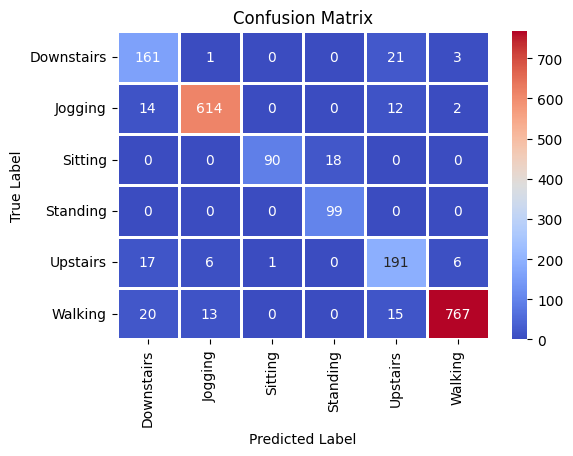

              precision    recall  f1-score   support

           0       0.76      0.87      0.81       186
           1       0.97      0.96      0.96       642
           2       0.99      0.83      0.90       108
           3       0.85      1.00      0.92        99
           4       0.80      0.86      0.83       221
           5       0.99      0.94      0.96       815

    accuracy                           0.93      2071
   macro avg       0.89      0.91      0.90      2071
weighted avg       0.93      0.93      0.93      2071



In [81]:
y_pred_test = model_m.predict(X_test)
max_y_pred_test = np.argmax(y_pred_test, axis=1)
max_y_test = np.argmax(y_test, axis=1)
show_confusion_matrix(max_y_test, max_y_pred_test)
print(classification_report(max_y_test, max_y_pred_test))

In [82]:
max_y_test.shape

(2071,)

# RNN으로 학습

In [ ]:
from keras.layers import GRU
model = Sequential()
model.add(Input(shape=(N,)))
model.add(Reshape((N,1)))
model.add(GRU(256, return_sequences=True, input_shape=(N,1)))
model.add(Dropout(0.2))
model.add(GRU(256))
model.add(Dropout(0.2))
model.add(Dense(6, activation='softmax'))

callbacks_list = [
    keras.callbacks.EarlyStopping(monitor='val_acc', patience=3, mode='max')
]
model.compile(loss='categorical_crossentropy',
                optimizer='adam', metrics=['accuracy'])
model.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 reshape_1 (Reshape)         (None, 100, 1)            0         
                                                                 
 gru (GRU)                   (None, 100, 256)          198912    
                                                                 
 dropout_1 (Dropout)         (None, 100, 256)          0         
                                                                 
 gru_1 (GRU)                 (None, 256)               394752    
                                                                 
 dropout_2 (Dropout)         (None, 256)               0         
                                                                 
 dense_7 (Dense)             (None, 6)                 1542      
                                                                 
Total params: 595,206
Trainable params: 595,206
Non-tr

Epoch 1/30
329/332 [============================>.] - ETA: 0s - loss: 0.9750 - accuracy: 0.6243

332/332 [==============================] - 10s 15ms/step - loss: 0.9732 - accuracy: 0.6252 - val_loss: 0.6082 - val_accuracy: 0.7797
Epoch 2/30
329/332 [============================>.] - ETA: 0s - loss: 0.5675 - accuracy: 0.7933

332/332 [==============================] - 5s 14ms/step - loss: 0.5668 - accuracy: 0.7936 - val_loss: 0.5544 - val_accuracy: 0.7966
Epoch 3/30
329/332 [============================>.] - ETA: 0s - loss: 0.4266 - accuracy: 0.8429

332/332 [==============================] - 4s 12ms/step - loss: 0.4258 - accuracy: 0.8432 - val_loss: 0.3979 - val_accuracy: 0.8678
Epoch 4/30
329/332 [============================>.] - ETA: 0s - loss: 0.3656 - accuracy: 0.8653

332/332 [==============================] - 4s 13ms/step - loss: 0.3658 - accuracy: 0.8652 - val_loss: 0.3657 - val_accuracy: 0.8727
Epoch 5/30
328/332 [============================>.] - ETA: 0s - loss: 0.3188 - accuracy: 0.8890

...

332/332 [==============================] - 4s 12ms/step - loss: 0.0354 - accuracy: 0.9879 - val_loss: 0.2869 - val_accuracy: 0.9306
Epoch 27/30
330/332 [============================>.] - ETA: 0s - loss: 0.0321 - accuracy: 0.9888

332/332 [==============================] - 4s 12ms/step - loss: 0.0320 - accuracy: 0.9888 - val_loss: 0.3363 - val_accuracy: 0.9143
Epoch 28/30
332/332 [==============================] - ETA: 0s - loss: 0.0333 - accuracy: 0.9878

332/332 [==============================] - 4s 13ms/step - loss: 0.0333 - accuracy: 0.9878 - val_loss: 0.3649 - val_accuracy: 0.9179
Epoch 29/30
330/332 [============================>.] - ETA: 0s - loss: 0.0438 - accuracy: 0.9850

332/332 [==============================] - 4s 12ms/step - loss: 0.0436 - accuracy: 0.9851 - val_loss: 0.3750 - val_accuracy: 0.9119
Epoch 30/30
329/332 [============================>.] - ETA: 0s - loss: 0.0484 - accuracy: 0.9824

65/65 [==============================] - 1s 8ms/step


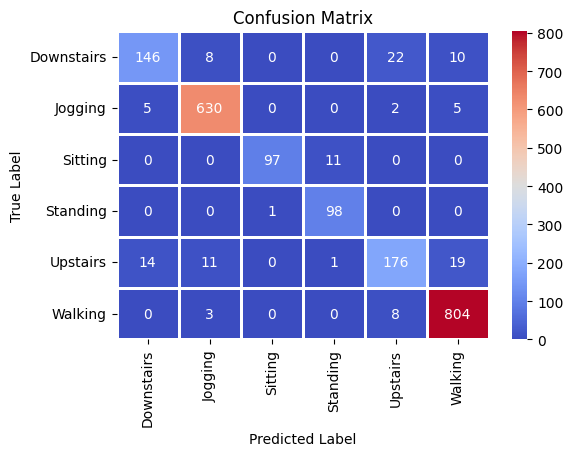

              precision    recall  f1-score   support

           0       0.88      0.78      0.83       186
           1       0.97      0.98      0.97       642
           2       0.99      0.90      0.94       108
           3       0.89      0.99      0.94        99
           4       0.85      0.80      0.82       221
           5       0.96      0.99      0.97       815

    accuracy                           0.94      2071
   macro avg       0.92      0.91      0.91      2071
weighted avg       0.94      0.94      0.94      2071



In [ ]:
history = model.fit(X_train,
                      y_train,
                      batch_size=BATCH_SIZE,
                      epochs=EPOCHS,
                      callbacks=callbacks_list,
                      validation_split=0.2,
                      verbose=1)

y_pred_test = model.predict(X_test)
max_y_pred_test = np.argmax(y_pred_test, axis=1)
max_y_test = np.argmax(y_test, axis=1)
show_confusion_matrix(max_y_test, max_y_pred_test)
print(classification_report(max_y_test, max_y_pred_test))

In [ ]:
model.evaluate(X_test, y_test)

65/65 [==============================] - 1s 10ms/step - loss: 0.2242 - accuracy: 0.9421


[0.22421444952487946, 0.9420569539070129]

# x,y,z 모두 사용할 때(Conv1D)

In [ ]:
X_3.shape

(10355, 100, 3)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_3, y_hot, test_size = 0.2)

model_m = Sequential()
model_m.add(Conv1D(64, 10, activation='relu',input_shape=(N,3)))
model_m.add(Conv1D(64, 10, activation='relu'))
model_m.add(MaxPooling1D(3))
model_m.add(Conv1D(128, 10, activation='relu'))
model_m.add(GlobalAveragePooling1D())
model_m.add(Dropout(0.5))
model_m.add(Dense(6, activation='softmax'))
# print(model_m.summary())

In [ ]:
callbacks_list = [
    keras.callbacks.ModelCheckpoint(
        filepath='best_model.{epoch:02d}-{val_loss:.2f}.h5',
        monitor='val_loss', save_best_only=True),
    keras.callbacks.EarlyStopping(monitor='val_acc', patience=3)
]

model_m.compile(loss='categorical_crossentropy',
                optimizer='adam', metrics=['accuracy'])

BATCH_SIZE = 20
EPOCHS = 30

history = model_m.fit(X_train,
                      y_train,
                      batch_size=BATCH_SIZE,
                      epochs=EPOCHS,
                      callbacks=callbacks_list,
                      validation_split=0.2,
                      verbose=1)

Epoch 1/30
332/332 [==============================] - ETA: 0s - loss: 0.6302 - accuracy: 0.7655

332/332 [==============================] - 4s 7ms/step - loss: 0.6302 - accuracy: 0.7655 - val_loss: 0.3377 - val_accuracy: 0.8847
Epoch 2/30
321/332 [============================>.] - ETA: 0s - loss: 0.3159 - accuracy: 0.8869

332/332 [==============================] - 2s 5ms/step - loss: 0.3142 - accuracy: 0.8882 - val_loss: 0.2157 - val_accuracy: 0.9294
Epoch 3/30
323/332 [============================>.] - ETA: 0s - loss: 0.1945 - accuracy: 0.9382

332/332 [==============================] - 2s 5ms/step - loss: 0.1933 - accuracy: 0.9390 - val_loss: 0.1549 - val_accuracy: 0.9541
Epoch 4/30
329/332 [============================>.] - ETA: 0s - loss: 0.1462 - accuracy: 0.9524

332/332 [==============================] - 2s 5ms/step - loss: 0.1462 - accuracy: 0.9525 - val_loss: 0.1269 - val_accuracy: 0.9565
Epoch 5/30
323/332 [============================>.] - ETA: 0s - loss: 0.1037 - accuracy: 0.9686

...

332/332 [==============================] - 2s 7ms/step - loss: 0.0157 - accuracy: 0.9961 - val_loss: 0.1083 - val_accuracy: 0.9747
Epoch 27/30
321/332 [============================>.] - ETA: 0s - loss: 0.0438 - accuracy: 0.9903

332/332 [==============================] - 2s 6ms/step - loss: 0.0425 - accuracy: 0.9906 - val_loss: 0.0467 - val_accuracy: 0.9867
Epoch 28/30
326/332 [============================>.] - ETA: 0s - loss: 0.0134 - accuracy: 0.9959

332/332 [==============================] - 2s 5ms/step - loss: 0.0134 - accuracy: 0.9958 - val_loss: 0.0517 - val_accuracy: 0.9867
Epoch 29/30
323/332 [============================>.] - ETA: 0s - loss: 0.0066 - accuracy: 0.9980

332/332 [==============================] - 2s 5ms/step - loss: 0.0083 - accuracy: 0.9979 - val_loss: 0.2363 - val_accuracy: 0.9541
Epoch 30/30
325/332 [============================>.] - ETA: 0s - loss: 0.0190 - accuracy: 0.9948

332/332 [==============================] - 2s 5ms/step - loss: 0.0187 - accuracy: 0.9949 - val_loss: 0.0682 - val_accuracy: 0.9819


65/65 [==============================] - 0s 3ms/step


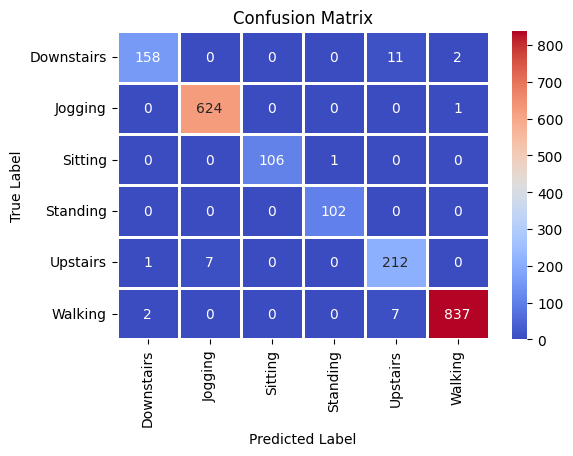

              precision    recall  f1-score   support

           0       0.98      0.92      0.95       171
           1       0.99      1.00      0.99       625
           2       1.00      0.99      1.00       107
           3       0.99      1.00      1.00       102
           4       0.92      0.96      0.94       220
           5       1.00      0.99      0.99       846

    accuracy                           0.98      2071
   macro avg       0.98      0.98      0.98      2071
weighted avg       0.98      0.98      0.98      2071



In [ ]:
y_pred_test = model_m.predict(X_test)
max_y_pred_test = np.argmax(y_pred_test, axis=1)
max_y_test = np.argmax(y_test, axis=1)
show_confusion_matrix(max_y_test, max_y_pred_test)
print(classification_report(max_y_test, max_y_pred_test))

# x,y,z, RNN

In [ ]:
from keras.layers import GRU
model = Sequential()
model.add(GRU(256, return_sequences=True, input_shape=(N,3)))
model.add(Dropout(0.2))
model.add(GRU(256))
model.add(Dropout(0.2))
model.add(Dense(classes, activation='softmax'))

callbacks_list = [
    keras.callbacks.EarlyStopping(monitor='val_acc', patience=3)
]
model.compile(loss='categorical_crossentropy',
                optimizer='adam', metrics=['accuracy'])
# model.summary()

Epoch 1/30
332/332 [==============================] - ETA: 0s - loss: 0.7881 - accuracy: 0.7270

332/332 [==============================] - 10s 15ms/step - loss: 0.7881 - accuracy: 0.7270 - val_loss: 0.4640 - val_accuracy: 0.8401
Epoch 2/30
331/332 [============================>.] - ETA: 0s - loss: 0.3449 - accuracy: 0.8769

332/332 [==============================] - 4s 13ms/step - loss: 0.3453 - accuracy: 0.8767 - val_loss: 0.2414 - val_accuracy: 0.9179
Epoch 3/30
332/332 [==============================] - ETA: 0s - loss: 0.2140 - accuracy: 0.9274

332/332 [==============================] - 5s 14ms/step - loss: 0.2140 - accuracy: 0.9274 - val_loss: 0.2044 - val_accuracy: 0.9366
Epoch 4/30
328/332 [============================>.] - ETA: 0s - loss: 0.1476 - accuracy: 0.9540

332/332 [==============================] - 4s 12ms/step - loss: 0.1473 - accuracy: 0.9540 - val_loss: 0.1518 - val_accuracy: 0.9517
Epoch 5/30
330/332 [============================>.] - ETA: 0s - loss: 0.1018 - accuracy: 0.9670

...

332/332 [==============================] - 5s 14ms/step - loss: 0.0054 - accuracy: 0.9983 - val_loss: 0.0710 - val_accuracy: 0.9807
Epoch 27/30
329/332 [============================>.] - ETA: 0s - loss: 0.0121 - accuracy: 0.9962

332/332 [==============================] - 4s 13ms/step - loss: 0.0121 - accuracy: 0.9962 - val_loss: 0.0678 - val_accuracy: 0.9849
Epoch 28/30
331/332 [============================>.] - ETA: 0s - loss: 0.0076 - accuracy: 0.9976

332/332 [==============================] - 4s 12ms/step - loss: 0.0076 - accuracy: 0.9976 - val_loss: 0.0929 - val_accuracy: 0.9843
Epoch 29/30
328/332 [============================>.] - ETA: 0s - loss: 0.0095 - accuracy: 0.9974

332/332 [==============================] - 4s 14ms/step - loss: 0.0095 - accuracy: 0.9974 - val_loss: 0.0757 - val_accuracy: 0.9819
Epoch 30/30
328/332 [============================>.] - ETA: 0s - loss: 0.0107 - accuracy: 0.9963

65/65 [==============================] - 1s 5ms/step


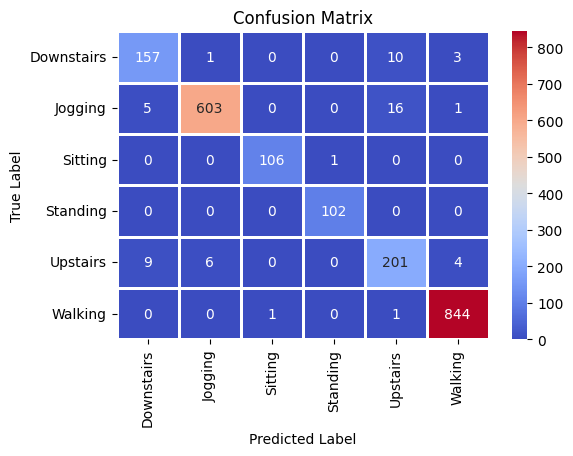

              precision    recall  f1-score   support

           0       0.92      0.92      0.92       171
           1       0.99      0.96      0.98       625
           2       0.99      0.99      0.99       107
           3       0.99      1.00      1.00       102
           4       0.88      0.91      0.90       220
           5       0.99      1.00      0.99       846

    accuracy                           0.97      2071
   macro avg       0.96      0.96      0.96      2071
weighted avg       0.97      0.97      0.97      2071



In [ ]:
history = model.fit(X_train,
                      y_train,
                      batch_size=BATCH_SIZE,
                      epochs=EPOCHS,
                      callbacks=callbacks_list,
                      validation_split=0.2,
                      verbose=1)

y_pred_test = model.predict(X_test)
max_y_pred_test = np.argmax(y_pred_test, axis=1)
max_y_test = np.argmax(y_test, axis=1)
show_confusion_matrix(max_y_test, max_y_pred_test)
print(classification_report(max_y_test, max_y_pred_test))

# All together

In [34]:
from matplotlib import pyplot as plt
%matplotlib inline
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

from sklearn import metrics
from sklearn.metrics import classification_report
from sklearn import preprocessing
from sklearn.model_selection import train_test_split

from tensorflow import keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, Reshape, GRU, Input
from tensorflow.keras.layers import Conv1D, Conv2D, MaxPooling1D, MaxPooling2D, GlobalAveragePooling1D
from tensorflow.keras import utils

In [35]:
LABELS = ['Downstairs',
          'Jogging',
          'Sitting',
          'Standing',
          'Upstairs',
          'Walking']

def read_data(file_path):
    column_names = ['user-id',
                    'activity',
                    'timestamp',
                    'x-axis',
                    'y-axis',
                    'z-axis']
    df = pd.read_csv(file_path,
                     header=None,
                     names=column_names,
                     on_bad_lines='skip')

    # 1. 마지막 컬럼의 문자열 내부에 포함된 ";"를 확실하게 제거
    df['z-axis'] = df['z-axis'].str.replace(';', '', regex=False)

    # 2. 판다스 내장 함수로 안전하고 빠르게 소수점 변환 (변환 실패 시 자동으로 NaN 처리)
    df['z-axis'] = pd.to_numeric(df['z-axis'], errors='coerce')

    # 3. 결측치 처리
    df = df.dropna(axis=0, how='any')

    return df

def convert_to_float(x):
    try:
        return np.float(x)
    except:
        return np.nan


df = read_data('./WISDM_ar_v1.1/WISDM_ar_v1.1_raw.txt')

In [36]:
pd.concat([df.head(3), df.tail(3)])

,user-id,activity,timestamp,x-axis,y-axis,z-axis
0,33,Jogging,49105962326000,-0.695,12.681,0.504
1,33,Jogging,49106062271000,5.012,11.264,0.953
2,33,Jogging,49106112167000,4.903,10.883,-0.082
1086463,19,Sitting,131623411592000,9.080,-1.380,1.690
1086464,19,Sitting,131623491487000,9.000,-1.460,1.730
1086465,19,Sitting,131623531465000,8.880,-1.330,1.610


In [37]:
df = df[df['timestamp'] > 0]        # 시각이 0이거나 음수인 샘플은 제외

le = preprocessing.LabelEncoder()
df['act'] = le.fit_transform(df['activity'].values)

sc = preprocessing.StandardScaler()
df[['x-axis', 'y-axis', 'z-axis']] = sc.fit_transform(df[['x-axis', 'y-axis', 'z-axis']])

In [38]:
# N개 샘플씩 끊어서 유효한 (통일된) 동작 레이블을 찾는다.
N = 100
X_all = []
y = []
for i in range(0, len(df)-N+1, N):
    z = stats.mode(df['act'][i: i+N])
    action, count = z[0], z[1]
    if count == N:
        xs = df['x-axis'].values[i: i + N]
        ys = df['y-axis'].values[i: i + N]
        zs = df['z-axis'].values[i: i + N]
        X_all.append([xs, ys, zs])
        y.append(action)

In [39]:
X_all = np.asarray(X_all, dtype= np.float32)
y = np.asarray(y)

In [40]:
X_all.shape, y.shape

((10355, 3, 100), (10355,))

In [41]:
X_3 = np.transpose(X_all, (0,2,1))  # input shape = (N,3)
y_hot = utils.to_categorical(y)     # one-hot encoding

In [42]:
X_3.shape, y_hot.shape

((10355, 100, 3), (10355, 6))

In [43]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_3, y_hot, test_size = 0.2)

In [ ]:
classes = len(df['act'].unique());   # 6 classes

model = Sequential()
model.add(Input(shape=(N,3)))
model.add(GRU(256, return_sequences=True))
model.add(Dropout(0.2))
model.add(GRU(256))
model.add(Dropout(0.2))
model.add(Dense(classes, activation='softmax'))

callbacks_list = [
    keras.callbacks.EarlyStopping(monitor='val_acc', patience=3)
]
model.compile(loss='categorical_crossentropy',
                optimizer='adam', metrics=['accuracy'])
# model.summary()

history = model.fit(X_train,
                      y_train,
                      batch_size=100,
                      epochs=2,
                      # callbacks=callbacks_list,
                      validation_split=0.2,
                      verbose=1)


In [48]:
y_pred_test = model.predict(X_test)
max_y_pred_test = np.argmax(y_pred_test, axis=1)
max_y_test = np.argmax(y_test, axis=1)
print(metrics.confusion_matrix(max_y_test, max_y_pred_test))
print(classification_report(max_y_test, max_y_pred_test))

65/65 ━━━━━━━━━━━━━━━━━━━━ 7s 107ms/step
[[  8   3   2   5  20 146]
 [  0 592   0   0   2  11]
 [  0   0  97   5   1   0]
 [  0   0   0  93  10   0]
 [  6  25   0  26  51 137]
 [  4   1   1   4  12 809]]
              precision    recall  f1-score   support

           0       0.44      0.04      0.08       184
           1       0.95      0.98      0.97       605
           2       0.97      0.94      0.96       103
           3       0.70      0.90      0.79       103
           4       0.53      0.21      0.30       245
           5       0.73      0.97      0.84       831

    accuracy                           0.80      2071
   macro avg       0.72      0.67      0.65      2071
weighted avg       0.76      0.80      0.75      2071



# Exercise

In [ ]:
# Regular string with escape characters
normal_string = "Hello\nWorld"
print(normal_string)

# Raw string with escape characters treated as literals
raw_string = r"Hello\nWorld"
print(raw_string)

Hello
World
Hello\nWorld
